In [26]:
from pathlib import Path 
import os 
import sys
import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample
import pickle as pkl
from scipy.spatial.distance import cdist 

In [27]:
# Sakurai medium concentrations
sakurai_medium = np.array([0, 0, 0, 70, 0, 0, 100, 0, 0, 0, 20, 14])

# Apply same transformation
sakurai_medium_log = np.log1p(sakurai_medium)

## Read data frames 

In [28]:
with open("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original/fitlered_populations.pkl", "rb") as file:
    filtered_df_original = pkl.load(file)

In [29]:
with open("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original_plus_LPHO012/fitlered_populations.pkl", "rb") as file:
    filtered_df_original_LPHO012 = pkl.load(file)

In [30]:
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]
protocol_cols = [name for name in protocol_cols]

## Concatenate

In [31]:
df_concatenated = {}

for cell_type in filtered_df_original:
    # Collect cell type specific values 
    df_original = filtered_df_original[cell_type]
    df_LPHO012 = filtered_df_original_LPHO012[cell_type]
    df_original["dataset"] = "Original"
    df_LPHO012["dataset"] = "LPH12"
    df_concatenated[cell_type] = pd.concat([df_original, df_LPHO012], axis=0)
    df_concatenated[cell_type]["sakurai_dist"] = cdist(df_concatenated[cell_type].loc[:, protocol_cols].values, sakurai_medium[None, :])

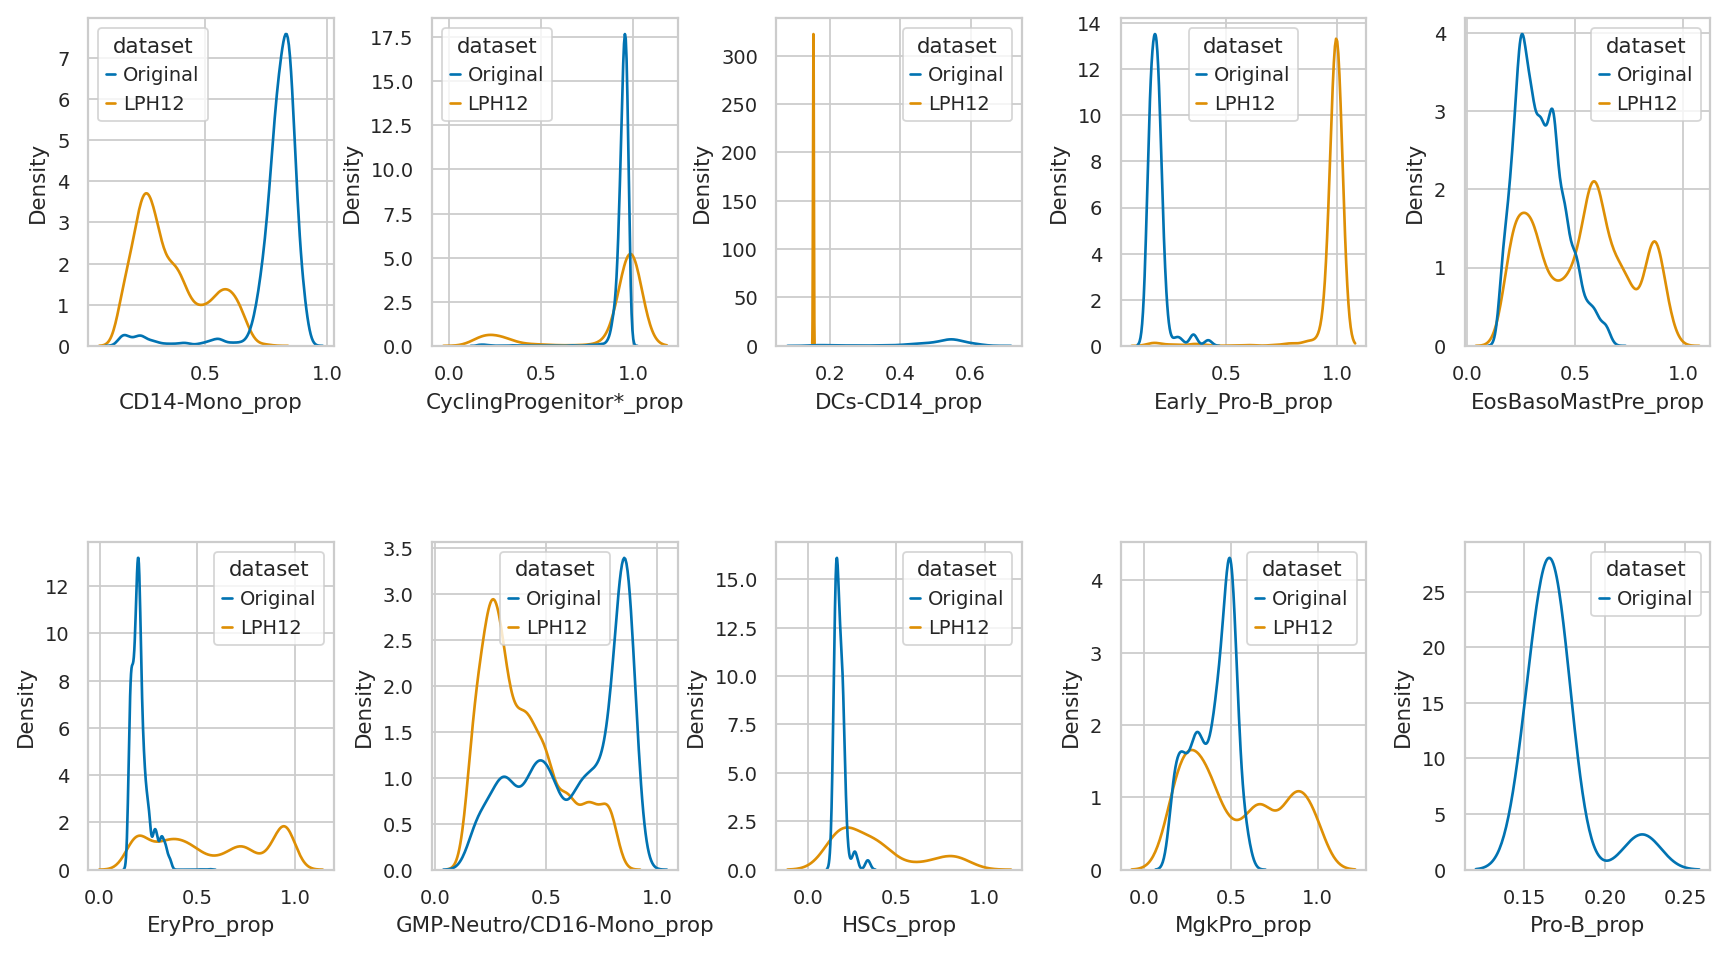

In [32]:
sns.set(style="whitegrid", context="paper")

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(13,7))
fig.subplots_adjust(
    hspace=0.6,   # vertical space between rows
    wspace=0.4    # horizontal space between columns
)
axes = axes.flatten()  # make indexing easy

for i, cell_type in enumerate(df_concatenated):
    cell_type_safe = cell_type.replace(":", "/")
    df_plot = df_concatenated[cell_type].reset_index(drop=True)

    ax = axes[i]

    sns.kdeplot(
        data=df_plot,
        x=f"{cell_type_safe}_prop",
        hue="dataset",
        ax=ax,
        common_norm=False,
        palette="colorblind"
    )


In [ ]:
sns.histplot(df_concatenated["MgkPro"], 
            x="MgkPro_prop", 
            hue="dataset",
            palette="colorblind")
plt.title("MgkPro proportion")
plt.show()

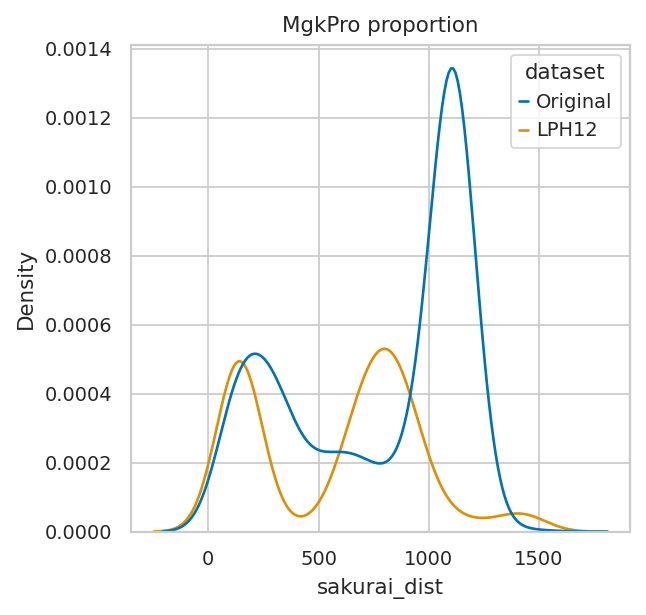

In [34]:
sns.kdeplot(df_concatenated["MgkPro"], 
            x="sakurai_dist", 
            hue="dataset",
            palette="colorblind")
plt.title("MgkPro proportion")
plt.show()

# Uncertainty comparisons

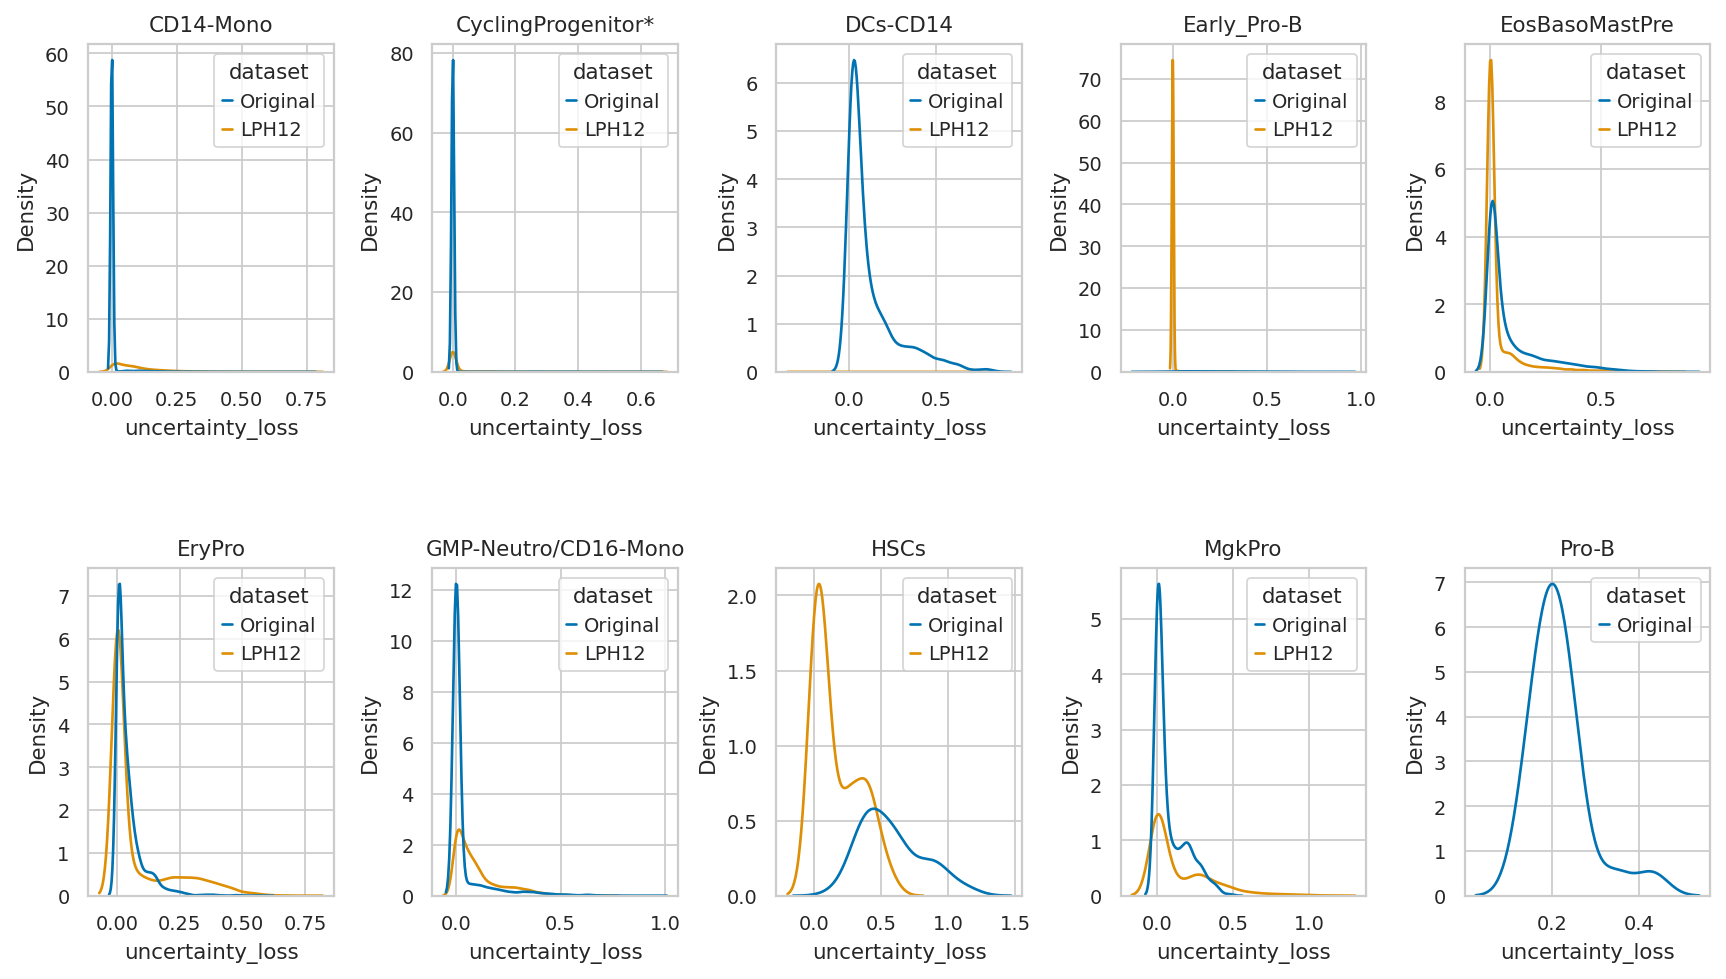

In [35]:
sns.set(style="whitegrid", context="paper")

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(13,7))
fig.subplots_adjust(
    hspace=0.6,   # vertical space between rows
    wspace=0.4    # horizontal space between columns
)
axes = axes.flatten()  # make indexing easy

for i, cell_type in enumerate(df_concatenated):
    cell_type_safe = cell_type.replace(":", "/")
    df_plot = df_concatenated[cell_type].reset_index(drop=True)

    ax = axes[i]

    sns.kdeplot(
        data=df_plot,
        x=f"uncertainty_loss",
        hue="dataset",
        ax=ax,
        common_norm=True,
        palette="colorblind",
    )
    ax.set_title(cell_type_safe)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = contour_func(


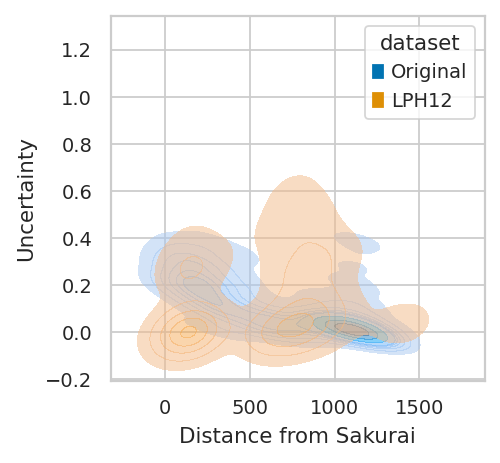

In [36]:
plt.figure(figsize=(3,3))
sns.kdeplot(
    data=df_concatenated["MgkPro"],
    x="sakurai_dist",
    y="uncertainty_loss",
    hue="dataset",
    fill=True,
    alpha=0.5,
    linewidth=1.5,
    levels=10,
    palette="colorblind",
    # clip=((None, None), (0, None))  # clip x and y at 0
    # cut=1
)

plt.ylabel("Uncertainty")
plt.xlabel("Distance from Sakurai")
plt.show()

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = contour_func(


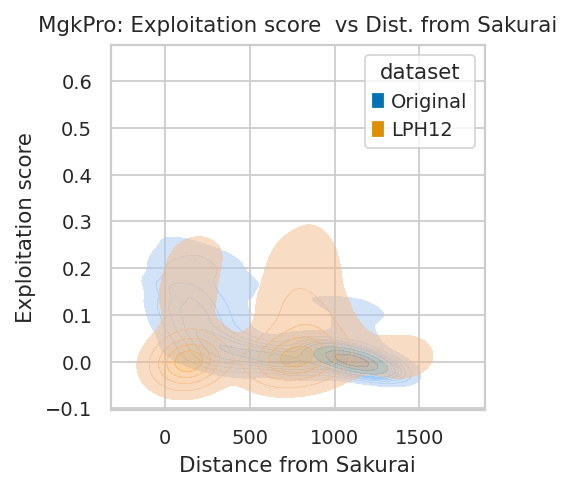

In [37]:
plt.figure(figsize=(3,3))
sns.kdeplot(
    data=df_concatenated["MgkPro"],
    x="sakurai_dist",
    y="exploitation_score",
    hue="dataset",
    fill=True,
    alpha=0.5,
    linewidth=1.5,
    levels=10,
    palette="colorblind",
    # clip=((None, None), (0, None))  # clip x and y at 0
    # cut=1
)

plt.ylabel("Exploitation score")
plt.xlabel("Distance from Sakurai")
plt.title("MgkPro: Exploitation score  vs Dist. from Sakurai")
plt.show()

Text(0.5, 1.0, 'MgkPro: Uncertainty distribution close solutions to Sakurai')

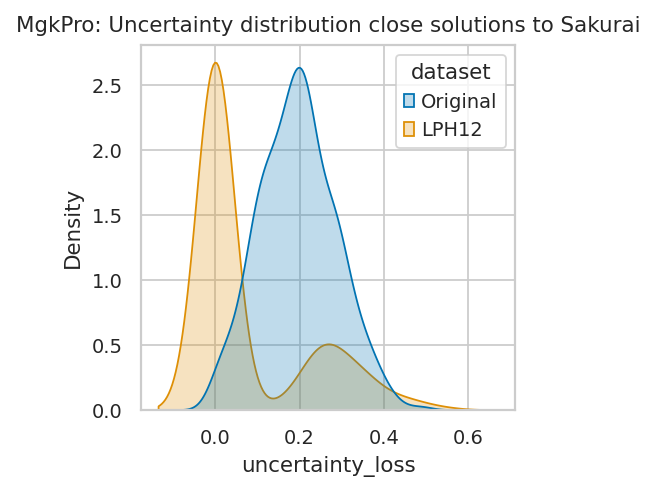

In [38]:
plt.figure(figsize=(3,3))
df_low = df_concatenated["MgkPro"].query("sakurai_dist <500")

sns.kdeplot(
    data=df_low,
    x="uncertainty_loss",
    hue="dataset",
    palette="colorblind",
    fill=True
)

plt.title("MgkPro: Uncertainty distribution close solutions to Sakurai")

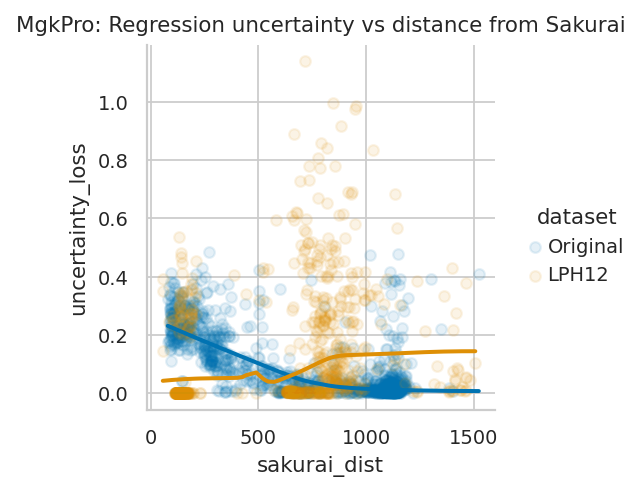

In [39]:
sns.lmplot(
    data=df_concatenated["MgkPro"],
    x="sakurai_dist",
    y="uncertainty_loss",
    palette="colorblind",
    hue="dataset",
    lowess=True,
    scatter_kws={"alpha":0.1},
    height=3,
    
)

plt.title("MgkPro: Regression uncertainty vs distance from Sakurai")
plt.show()

## Read unique concentrations and evaluate how uncertainty changed 

In [40]:
sc.settings.set_figure_params(figsize=(4, 4))

/tmp/ipykernel_3875388/3534239246.py:1: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(figsize=(4, 4))


In [41]:
# Read unique solutions 
unique_solutions = sc.read_h5ad(
    "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/miscellaneous/unique_concentrations_adata.h5ad"
)

# Create AnnData object for Sakurai
sakurai = sc.AnnData(
    X=sakurai_medium_log[None, :],
    var=unique_solutions.var.copy()
)

sakurai.obs["is_sakurai"] = True

# Mark existing data
unique_solutions.obs["is_sakurai"] = False

# Concatenate datasets
unique_solutions_sakurai = sc.concat(
    [unique_solutions, sakurai],
    axis=0
)

# Recompute PCA
sc.tl.pca(unique_solutions_sakurai)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


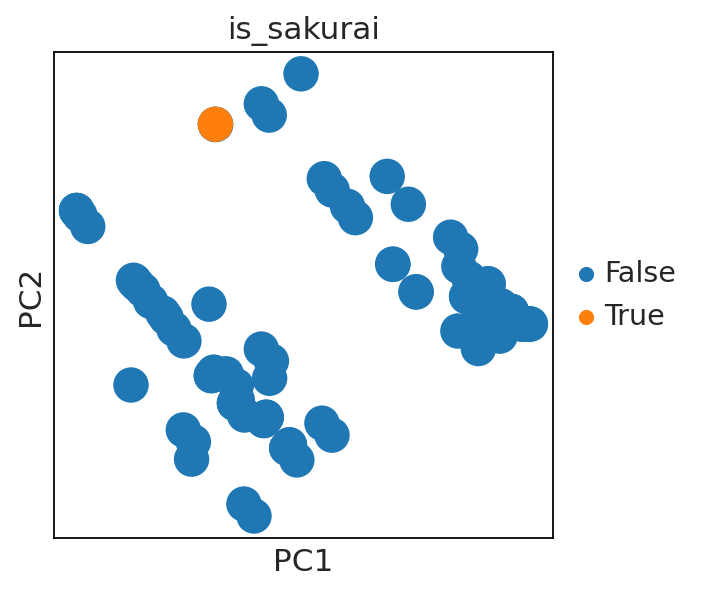

In [42]:
sc.pl.pca(unique_solutions_sakurai, color="is_sakurai")

## Project generated solutions onto PCs and visualize PCA plot 

In [43]:
mgkpro_original = filtered_df_original["MgkPro"]
mgkpro_original_plus_lpho012 = filtered_df_original_LPHO012["MgkPro"]

mgkpro_original_vals = np.log1p(mgkpro_original.loc[:, protocol_cols].values)
mgkpro_original_plus_lpho012_vals = np.log1p(mgkpro_original_plus_lpho012.loc[:, protocol_cols].values)

In [44]:
np.max(mgkpro_original_vals, axis=0)

array([1.4696765 , 1.55812811, 5.42633773, 7.37259007, 3.94123534,
       1.63462094, 4.88960404, 3.16331005, 1.90810399, 3.42017696,
       2.98209333, 3.04399635])

In [45]:
np.max(mgkpro_original_plus_lpho012_vals, axis=0)

array([3.02369237, 1.6989437 , 7.31350135, 6.31531424, 0.80555178,
       4.06799651, 4.86813688, 2.14900014, 3.93475721, 3.10892367,
       3.11485841, 3.04272721])

In [48]:
generated_solutions = sc.AnnData(X=np.concatenate([mgkpro_original_vals, 
                                                   mgkpro_original_plus_lpho012_vals], axis=0), 
                                 obs={"dataset": ["original" for _ in range(len(mgkpro_original_vals))] + \
                                      ["LPHO012" for _ in range(len(mgkpro_original_plus_lpho012_vals))]})

In [61]:
generated_solutions.obsm["X_pca"] = (generated_solutions.X - \
                                     unique_solutions_sakurai.X.mean(0)[None, :]).dot(unique_solutions_sakurai.varm["PCs"])

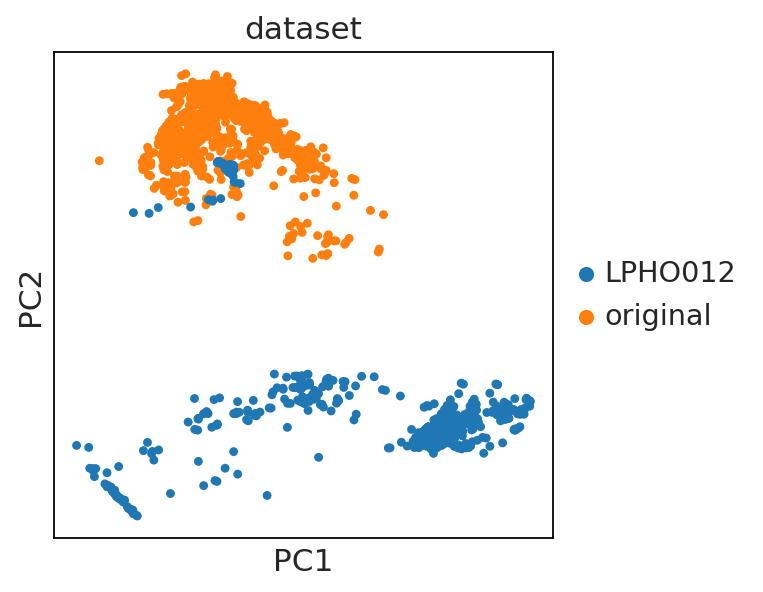

In [62]:
sc.pl.pca(generated_solutions, color="dataset")

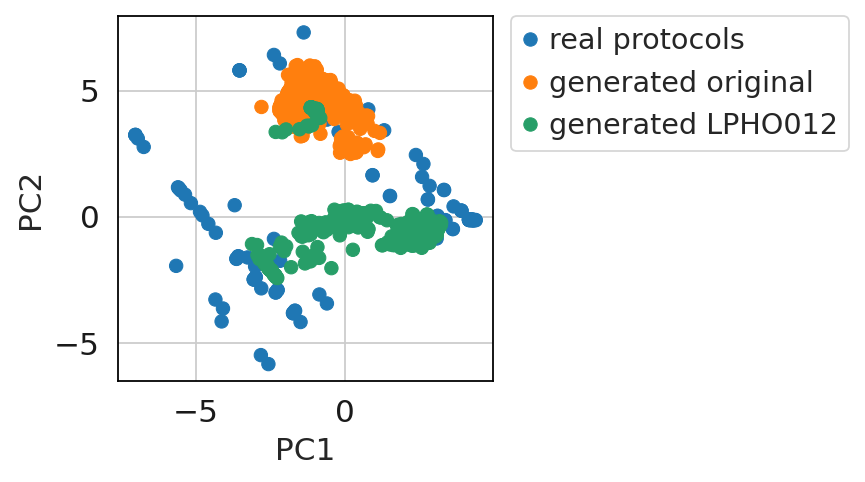

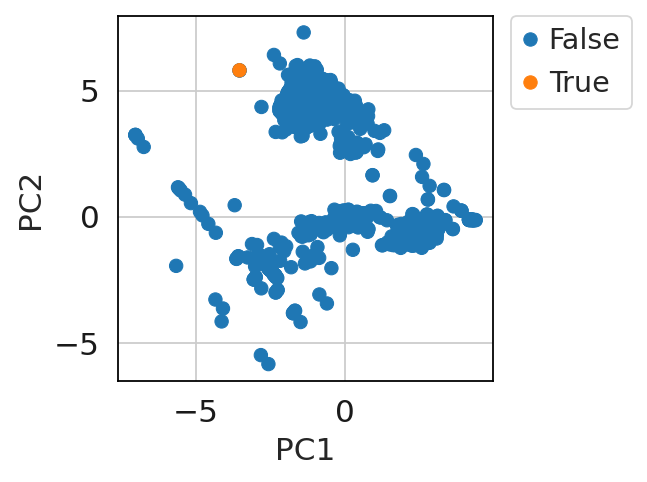

In [63]:
PC1 = np.concatenate([unique_solutions_sakurai.obsm["X_pca"][:, 0], 
                      generated_solutions.obsm["X_pca"][:,0]])
PC2 = np.concatenate([unique_solutions_sakurai.obsm["X_pca"][:, 1], 
                      generated_solutions.obsm["X_pca"][:,1]])
annotation = ["real protocols" for _ in range(len(unique_solutions_sakurai))] + \
["generated original" for _ in range(len(mgkpro_original_vals))] + \
["generated LPHO012" for _ in range(len(mgkpro_original_plus_lpho012_vals))]

is_sakurai = unique_solutions_sakurai.obs["is_sakurai"].to_list() + [False for _ in range(len(generated_solutions))]

pcs_to_plot = pd.DataFrame({"PC1": PC1, 
                           "PC2": PC2, 
                           "Dataset": annotation, 
                           "is_Sakurai": is_sakurai})

plt.figure(figsize=(3,3))
ax = sns.scatterplot(data=pcs_to_plot,
                x="PC1", 
                y="PC2",
                hue="Dataset",
                edgecolor=None)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.figure(figsize=(3,3))
ax = sns.scatterplot(data=pcs_to_plot,
                x="PC1", 
                y="PC2",
                hue="is_Sakurai",
                edgecolor=None)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

**Try PCA of all together**

In [82]:
adata_concat_real_generated = sc.AnnData(X=np.concatenate([unique_solutions_sakurai.X, mgkpro_original_vals, mgkpro_original_plus_lpho012_vals], 
                                                          axis=0), 
                                        obs=pcs_to_plot)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [95]:
pcs_to_plot

,PC1,PC2,Dataset,is_Sakurai
0,-7.014120,3.246397,real protocols,False
1,-7.013185,3.244872,real protocols,False
2,-7.012310,3.243445,real protocols,False
3,-7.007993,3.236404,real protocols,False
4,-3.537132,5.808525,real protocols,False
...,...,...,...,...
2001,1.860651,-0.283680,generated LPHO012,False
2002,1.718834,-0.349713,generated LPHO012,False
2003,2.238507,-0.751527,generated LPHO012,False
2004,1.986085,-0.681058,generated LPHO012,False


In [83]:
sc.tl.pca(adata_concat_real_generated)

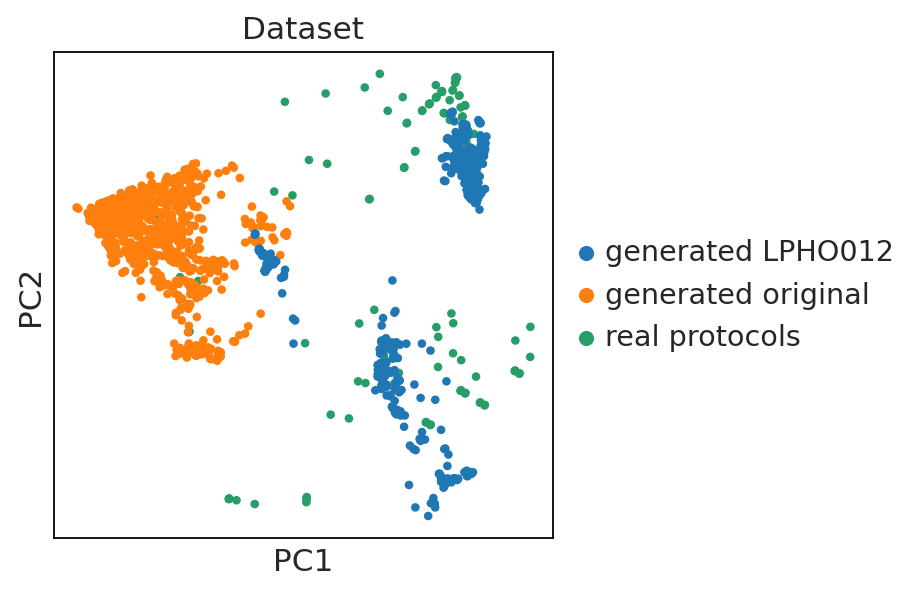

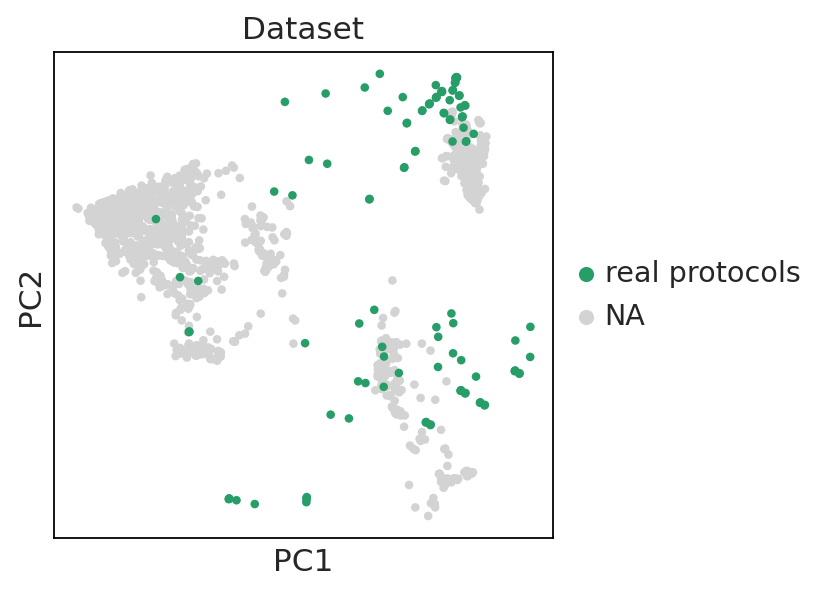

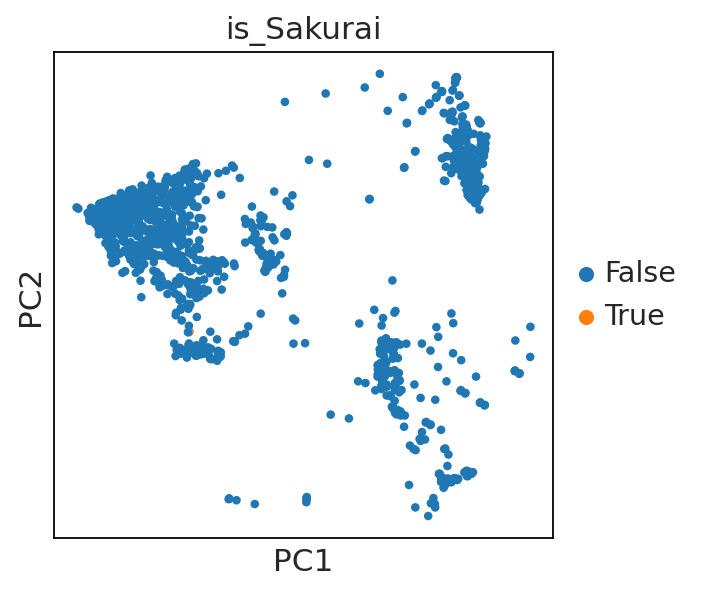

In [91]:
sc.pl.pca(adata_concat_real_generated, color="Dataset")
sc.pl.pca(adata_concat_real_generated, color="Dataset", groups="real protocols")
sc.pl.pca(adata_concat_real_generated, color="is_Sakurai", groups=[True])

In [99]:
adata_concat_real_generated.obs.Dataset.value_counts()

Dataset
generated original    1219
generated LPHO012      669
real protocols         118
Name: count, dtype: int64

In [101]:
sc.pp.neighbors(adata_concat_real_generated)
sc.tl.umap(adata_concat_real_generated)

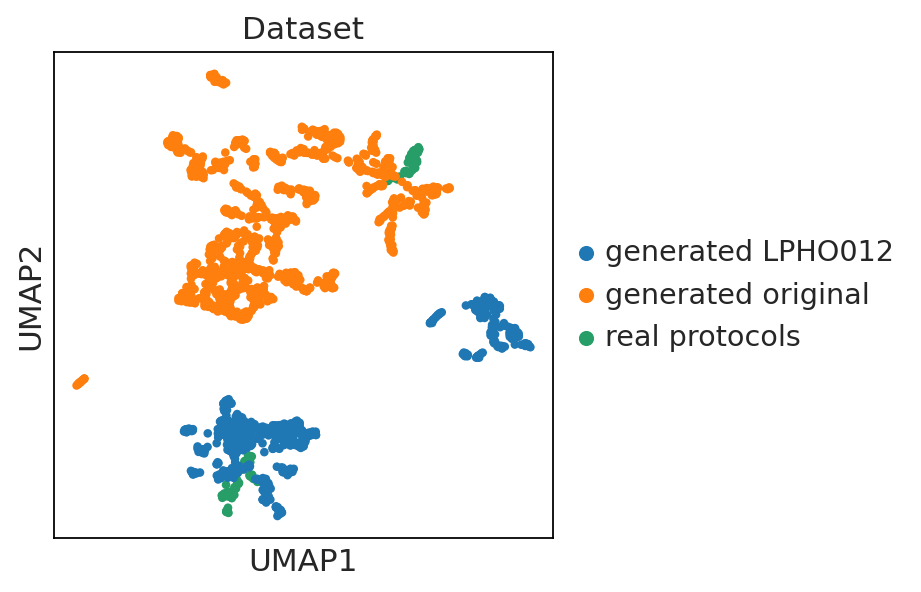

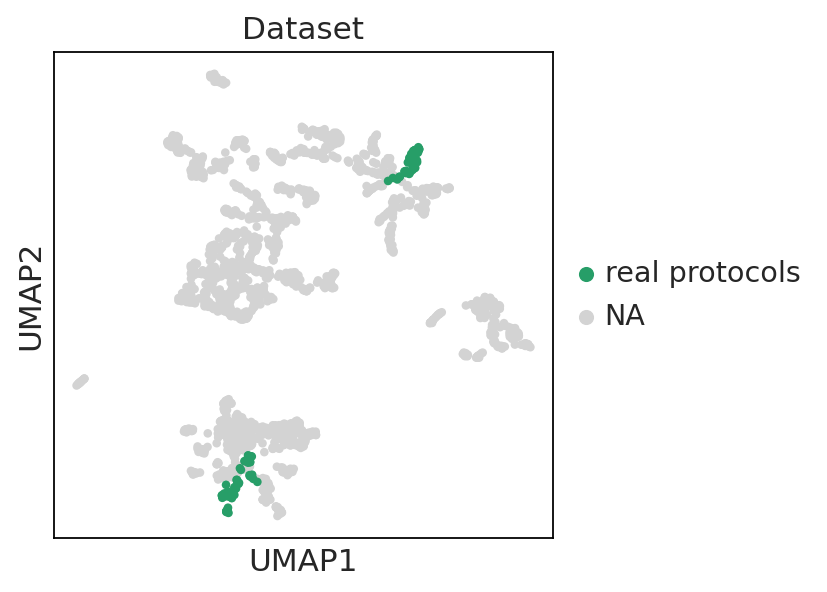

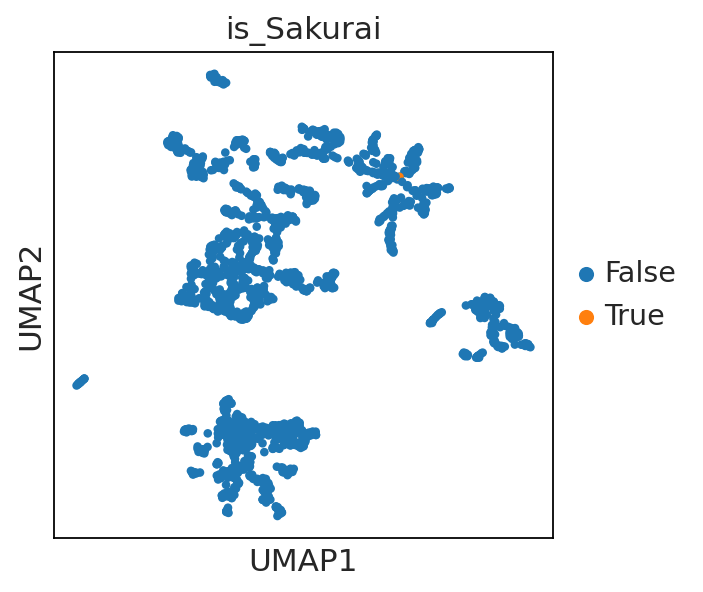

In [102]:
sc.pl.umap(adata_concat_real_generated, color="Dataset")
sc.pl.umap(adata_concat_real_generated, color="Dataset", groups="real protocols")
sc.pl.umap(adata_concat_real_generated, color="is_Sakurai", groups=[True])